In [52]:
import shutil

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

In [53]:
#Install & Imports
%pip install opencv-python-headless Pillow matplotlib seaborn tqdm pyyaml imagehash --quiet

import os
import glob
import shutil
import random
import zipfile
import yaml
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
from PIL import Image
import imagehash
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [54]:
#Configuration (Edit this before running anything else)


ZIP_PATH = "archive.zip"


CLASS_NAMES = ["drone"]


TRAIN_RATIO = 0.70
VAL_RATIO   = 0.20
TEST_RATIO  = 0.10

OUTPUT_DIR     = "dataset_clean"
MIN_DIM        = 32
BLUR_THRESHOLD = 50.0
SEED           = 42
EXTRACT_DIR    = "dataset_raw"


assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6, \
    "Ratios must sum to 1.0!"

print(" Config set!")
print(f"   ZIP file    : {ZIP_PATH}")
print(f"   Classes     : {CLASS_NAMES}")
print(f"   Split       : Train={int(TRAIN_RATIO*100)}% | Val={int(VAL_RATIO*100)}% | Test={int(TEST_RATIO*100)}%")
print(f"   Output dir  : {OUTPUT_DIR}")

 Config set!
   ZIP file    : archive.zip
   Classes     : ['drone']
   Split       : Train=70% | Val=20% | Test=10%
   Output dir  : dataset_clean


In [55]:
# Cell 3 — Extract & Inventory

# Extract zip
if not os.path.exists(EXTRACT_DIR):
    print(f"Extracting {ZIP_PATH} ...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    print(f"Extracted to '{EXTRACT_DIR}/'")
else:
    print(f"'{EXTRACT_DIR}/' already exists, skipping extraction.")

# Find all images and labels recursively
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

all_images = [
    Path(p) for p in glob.glob(f"{EXTRACT_DIR}/**/*", recursive=True)
    if Path(p).suffix.lower() in IMG_EXTS
]
all_labels = [
    Path(p) for p in glob.glob(f"{EXTRACT_DIR}/**/*.txt", recursive=True)
]

# Index labels by filename stem (no extension)
label_index = {lbl.stem: lbl for lbl in all_labels}

# Build inventory
inventory = []
for img in all_images:
    lbl = label_index.get(img.stem)
    inventory.append({
        "image"    : img,
        "label"    : lbl,
        "has_label": lbl is not None
    })

# Report
with_lbl = sum(1 for x in inventory if x["has_label"])
no_lbl   = len(inventory) - with_lbl

print(f"\nINVENTORY REPORT")
print(f"{'-'*35}")
print(f"  Total images found   : {len(inventory)}")
print(f"  Images with labels   : {with_lbl}")
print(f"  Images without labels: {no_lbl}")
print(f"  Total .txt files     : {len(all_labels)}")
print(f"{'-'*35}")

if no_lbl > 0:
    print("\nImages missing a label file:")
    for x in inventory:
        if not x["has_label"]:
            print(f"  - {x['image'].name}")

'dataset_raw/' already exists, skipping extraction.

INVENTORY REPORT
-----------------------------------
  Total images found   : 4014
  Images with labels   : 4010
  Images without labels: 4
  Total .txt files     : 4010
-----------------------------------

Images missing a label file:
  - video18_1999.JPEG
  - video15_487.JPEG
  - 10005.jpeg
  - 1007.jpeg


In [56]:
# Cell 4 — Image Validation

img_report = []
hash_seen  = {}
ISSUES     = defaultdict(list)

print("Validating images...")
for item in tqdm(inventory, desc="Scanning"):
    p = item["image"]
    r = {"path": p, "valid": True, "issues": [], "width": None, "height": None, "blur": None}

    # 1. Corruption check
    try:
        pil = Image.open(p).convert("RGB")
        w, h = pil.size
        r["width"], r["height"] = w, h
    except Exception as e:
        r["valid"] = False
        r["issues"].append(f"CORRUPT: {e}")
        ISSUES["corrupt"].append(p.name)
        img_report.append(r)
        item["img_report"] = r
        continue

    # 2. Minimum dimension check
    if w < MIN_DIM or h < MIN_DIM:
        r["issues"].append(f"TOO_SMALL: {w}x{h}")
        ISSUES["too_small"].append(p.name)

    # 3. Blur check (Laplacian variance)
    gray = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2GRAY)
    lap  = cv2.Laplacian(gray, cv2.CV_64F).var()
    r["blur"] = round(lap, 2)
    if lap < BLUR_THRESHOLD:
        r["issues"].append(f"BLURRY: variance={lap:.1f}")
        ISSUES["blurry"].append(p.name)

    # 4. Duplicate check (perceptual hash)
    ph = str(imagehash.phash(pil))
    if ph in hash_seen:
        r["issues"].append(f"DUPLICATE of {hash_seen[ph].name}")
        ISSUES["duplicate"].append(p.name)
    else:
        hash_seen[ph] = p

    if r["issues"]:
        r["valid"] = False

    img_report.append(r)
    item["img_report"] = r
    item["width"]  = r["width"]
    item["height"] = r["height"]

# Report
valid_count   = sum(1 for r in img_report if r["valid"])
invalid_count = len(img_report) - valid_count

print(f"\nIMAGE VALIDATION REPORT")
print(f"{'-'*35}")
print(f"  Valid images   : {valid_count}")
print(f"  Flagged images : {invalid_count}")
for k, v in ISSUES.items():
    print(f"    {k.upper():<18}: {len(v)}")
print(f"{'-'*35}")

Validating images...


Scanning: 100%|██████████| 4014/4014 [01:35<00:00, 41.90it/s]


IMAGE VALIDATION REPORT
-----------------------------------
  Valid images   : 2481
  Flagged images : 1533
    BLURRY            : 600
    DUPLICATE         : 1008
    CORRUPT           : 3
-----------------------------------


In [57]:
# Cell 5 — Label Validation

lbl_issues  = defaultdict(list)
NUM_CLASSES = len(CLASS_NAMES)

print("Validating labels...")
for item in tqdm([x for x in inventory if x["has_label"]], desc="Labels"):
    lp = item["label"]
    r  = {"path": lp, "valid": True, "issues": [], "boxes": [], "num_boxes": 0}

    # Read file
    try:
        lines = lp.read_text().strip().splitlines()
    except Exception as e:
        r["valid"] = False
        r["issues"].append(f"READ_ERROR: {e}")
        item["lbl_report"] = r
        continue

    # Empty label file (background image — acceptable)
    if not lines:
        r["issues"].append("EMPTY_LABEL")
        lbl_issues["empty"].append(lp.name)
        item["lbl_report"] = r
        continue

    boxes = []
    for i, line in enumerate(lines):
        parts = line.strip().split()

        # Must have exactly 5 values
        if len(parts) != 5:
            r["issues"].append(f"Line {i}: bad format — {len(parts)} values instead of 5")
            lbl_issues["bad_format"].append(lp.name)
            r["valid"] = False
            continue

        # Must all be numeric
        try:
            cls = int(parts[0])
            xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        except ValueError:
            r["issues"].append(f"Line {i}: non-numeric values")
            lbl_issues["not_numeric"].append(lp.name)
            r["valid"] = False
            continue

        box_issues = []

        # Class ID must be valid
        if cls < 0 or cls >= NUM_CLASSES:
            box_issues.append(f"INVALID_CLASS: {cls}")
            lbl_issues["invalid_class"].append(lp.name)
            r["valid"] = False

        # Coordinates must be in [0, 1] — flagged but fixable
        if any(v < 0 or v > 1 for v in [xc, yc, bw, bh]):
            box_issues.append(f"OUT_OF_BOUNDS: [{xc:.3f},{yc:.3f},{bw:.3f},{bh:.3f}]")
            lbl_issues["out_of_bounds"].append(lp.name)

        # Zero-area box is useless
        if bw <= 0 or bh <= 0:
            box_issues.append(f"ZERO_AREA: w={bw}, h={bh}")
            lbl_issues["zero_area"].append(lp.name)
            r["valid"] = False

        boxes.append({"cls": cls, "xc": xc, "yc": yc, "w": bw, "h": bh, "issues": box_issues})
        if box_issues:
            r["issues"].append(f"Line {i}: {box_issues}")

    r["boxes"]     = boxes
    r["num_boxes"] = len(boxes)
    item["lbl_report"] = r

# Report
total_checked = len([x for x in inventory if x["has_label"]])
total_issues  = sum(len(v) for v in lbl_issues.values())

print(f"\nLABEL VALIDATION REPORT")
print(f"{'-'*35}")
print(f"  Labels checked : {total_checked}")
print(f"  Clean labels   : {total_checked - len(set(sum(lbl_issues.values(), [])))}")
print(f"  Issues found   : {total_issues}")
for k, v in lbl_issues.items():
    print(f"    {k.upper():<20}: {len(set(v))} file(s)")
print(f"{'-'*35}")

Validating labels...


Labels: 100%|██████████| 4010/4010 [00:00<00:00, 29215.30it/s]


LABEL VALIDATION REPORT
-----------------------------------
  Labels checked : 4010
  Clean labels   : 2865
  Issues found   : 1145
    EMPTY               : 1145 file(s)
-----------------------------------


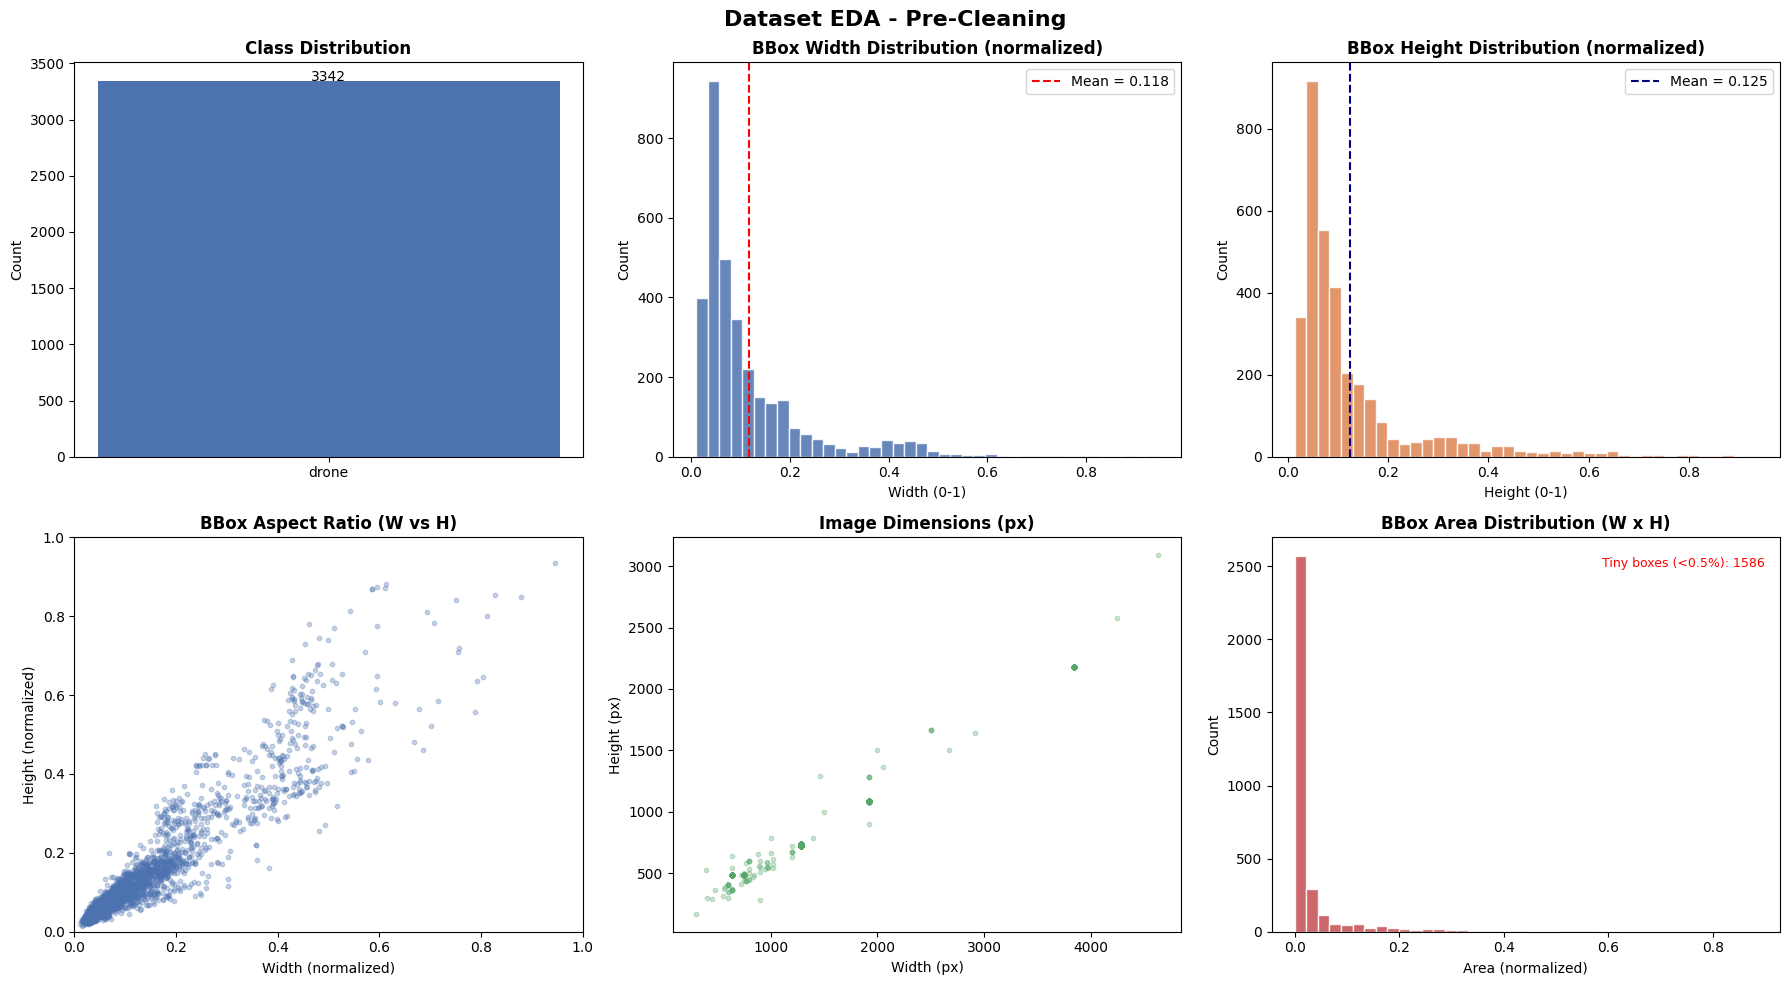

EDA chart saved as eda_report.png


In [58]:
# Cell 6 — EDA

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Dataset EDA - Pre-Cleaning", fontsize=16, fontweight="bold")

bw_list, bh_list, ba_list, iw_list, ih_list = [], [], [], [], []
class_counts = defaultdict(int)

for item in inventory:
    if item.get("lbl_report"):
        for box in item["lbl_report"]["boxes"]:
            name = CLASS_NAMES[box["cls"]] if box["cls"] < len(CLASS_NAMES) else f"cls_{box['cls']}"
            class_counts[name] += 1
            bw_list.append(box["w"])
            bh_list.append(box["h"])
            ba_list.append(box["w"] * box["h"])
    if item.get("width"):
        iw_list.append(item["width"])
        ih_list.append(item["height"])

# 1. Class distribution
ax = axes[0, 0]
if class_counts:
    ck, cv = list(class_counts.keys()), list(class_counts.values())
    bars = ax.bar(ck, cv, color="#4C72B0")
    for bar, cnt in zip(bars, cv):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(cnt), ha="center", fontsize=10)
ax.set_title("Class Distribution", fontweight="bold")
ax.set_ylabel("Count")

# 2. BBox width distribution
ax = axes[0, 1]
if bw_list:
    ax.hist(bw_list, bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(float(np.mean(bw_list)), color="red", linestyle="--",
               label=f"Mean = {np.mean(bw_list):.3f}")
    ax.legend()
ax.set_title("BBox Width Distribution (normalized)", fontweight="bold")
ax.set_xlabel("Width (0-1)")
ax.set_ylabel("Count")

# 3. BBox height distribution
ax = axes[0, 2]
if bh_list:
    ax.hist(bh_list, bins=40, color="#DD8452", edgecolor="white", alpha=0.85)
    ax.axvline(float(np.mean(bh_list)), color="navy", linestyle="--",
               label=f"Mean = {np.mean(bh_list):.3f}")
    ax.legend()
ax.set_title("BBox Height Distribution (normalized)", fontweight="bold")
ax.set_xlabel("Height (0-1)")
ax.set_ylabel("Count")

# 4. BBox aspect ratio scatter
ax = axes[1, 0]
if bw_list:
    ax.scatter(bw_list, bh_list, alpha=0.3, s=10, c="#4C72B0")
ax.set_title("BBox Aspect Ratio (W vs H)", fontweight="bold")
ax.set_xlabel("Width (normalized)")
ax.set_ylabel("Height (normalized)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# 5. Image dimensions scatter
ax = axes[1, 1]
if iw_list:
    ax.scatter(iw_list, ih_list, alpha=0.3, s=10, c="#55A868")
ax.set_title("Image Dimensions (px)", fontweight="bold")
ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")

# 6. BBox area distribution
ax = axes[1, 2]
if ba_list:
    ax.hist(ba_list, bins=40, color="#C44E52", edgecolor="white", alpha=0.85)
    small = sum(1 for a in ba_list if a < 0.005)
    ax.text(0.97, 0.95, f"Tiny boxes (<0.5%): {small}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9, color="red")
ax.set_title("BBox Area Distribution (W x H)", fontweight="bold")
ax.set_xlabel("Area (normalized)")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA chart saved as eda_report.png")

In [59]:
# Cell 7 — Auto-Fix

# Minimum bbox area to keep (W x H normalized)
# Boxes smaller than this are likely too tiny to learn from
MIN_BBOX_AREA = 0.0005   # 0.05% of image — adjust if needed

fix_log = {
    "removed_corrupt"   : [],
    "removed_duplicate" : [],
    "removed_blurry"    : [],
    "removed_no_label"  : [],
    "labels_clipped"    : [],
    "tiny_boxes_removed": 0,
    "empty_labels_removed": []   # ✅ NEW
}

clean_inventory = []
seen_clean      = set()

print("Applying fixes...")
for item in tqdm(inventory, desc="Fixing"):
    p      = item["image"]
    issues = item.get("img_report", {}).get("issues", [])
    skip   = False

    # Remove corrupt
    if any("CORRUPT" in iss for iss in issues):
        fix_log["removed_corrupt"].append(p.name)
        skip = True

    # Remove blurry
    if not skip and any("BLURRY" in iss for iss in issues):
        fix_log["removed_blurry"].append(p.name)
        skip = True

    # Remove duplicates — keep only first occurrence
    if not skip:
        try:
            ph = str(imagehash.phash(Image.open(p).convert("RGB")))
        except:
            ph = None
        if ph and ph in seen_clean:
            fix_log["removed_duplicate"].append(p.name)
            skip = True
        elif ph:
            seen_clean.add(ph)

    # Skip images with no label file
    if not skip and not item["has_label"]:
        fix_log["removed_no_label"].append(p.name)
        skip = True

    if skip:
        continue

    # Fix label: clip OOB coords + remove tiny boxes
    fixed_lines = []
    if item.get("lbl_report"):
        for box in item["lbl_report"]["boxes"]:
            xc = max(0.0, min(1.0, box["xc"]))
            yc = max(0.0, min(1.0, box["yc"]))
            bw = max(0.0, min(1.0, box["w"]))
            bh = max(0.0, min(1.0, box["h"]))

            # Skip zero-area boxes
            if bw <= 0 or bh <= 0:
                continue

            # Skip tiny boxes
            if bw * bh < MIN_BBOX_AREA:
                fix_log["tiny_boxes_removed"] += 1
                continue

            # Log if coords were clipped
            if (xc, yc, bw, bh) != (box["xc"], box["yc"], box["w"], box["h"]):
                fix_log["labels_clipped"].append(item["label"].name)

            fixed_lines.append(f"{box['cls']} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")


    if len(fixed_lines) == 0:
        fix_log["empty_labels_removed"].append(p.name)
        continue

    item["fixed_lines"] = fixed_lines
    clean_inventory.append(item)

print(f"\nFIX LOG")
print(f"{'-'*35}")
print(f"  Corrupt removed     : {len(fix_log['removed_corrupt'])}")
print(f"  Blurry removed      : {len(fix_log['removed_blurry'])}")
print(f"  Duplicates removed  : {len(fix_log['removed_duplicate'])}")
print(f"  No-label skipped    : {len(fix_log['removed_no_label'])}")
print(f"  Empty labels removed: {len(fix_log['empty_labels_removed'])}")  # ✅ NEW
print(f"  Labels clipped      : {len(set(fix_log['labels_clipped']))}")
print(f"  Tiny boxes removed  : {fix_log['tiny_boxes_removed']}")
print(f"{'-'*35}")
print(f"  Clean images remaining: {len(clean_inventory)}")

Applying fixes...


Fixing: 100%|██████████| 4014/4014 [00:48<00:00, 83.49it/s]


FIX LOG
-----------------------------------
  Corrupt removed     : 3
  Blurry removed      : 600
  Duplicates removed  : 930
  No-label skipped    : 2
  Empty labels removed: 867
  Labels clipped      : 0
  Tiny boxes removed  : 5
-----------------------------------
  Clean images remaining: 1612


In [60]:
# Cell 8 — Train / Val / Test Split

import random

random.seed(SEED)

# ✅ Only use images that have NON-EMPTY labels
labeled = [
    x for x in clean_inventory
    if x["has_label"] and x.get("fixed_lines") and len(x["fixed_lines"]) > 0
]

unlabeled = [x for x in clean_inventory if not x["has_label"]]

random.shuffle(labeled)

n       = len(labeled)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)

train_set = labeled[:n_train]
val_set   = labeled[n_train:n_train + n_val]
test_set  = labeled[n_train + n_val:]

print(f"SPLIT REPORT")
print(f"{'-'*35}")
print(f"  Total clean labeled  : {n}")
print(f"  Train  ({int(TRAIN_RATIO*100)}%) : {len(train_set)}")
print(f"  Val    ({int(VAL_RATIO*100)}%) : {len(val_set)}")
print(f"  Test   ({int(TEST_RATIO*100)}%) : {len(test_set)}")
if unlabeled:
    print(f"  Background (no bbox) : {len(unlabeled)} (not included in split)")
print(f"{'-'*35}")

SPLIT REPORT
-----------------------------------
  Total clean labeled  : 1612
  Train  (70%) : 1128
  Val    (20%) : 322
  Test   (10%) : 162
-----------------------------------


In [61]:
# Cell 9 — Build Output Directory

# Cell 9 — Build Output Directory

from shutil import copy2

def build_split(items, split_name):
    img_dir = Path(OUTPUT_DIR) / split_name / "images"
    lbl_dir = Path(OUTPUT_DIR) / split_name / "labels"
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    count = 0

    for item in items:
        # Skip if label is missing or empty (FINAL SAFETY CHECK)
        if not item.get("fixed_lines") or len(item["fixed_lines"]) == 0:
            continue

        # Copy image
        copy2(item["image"], img_dir / item["image"].name)

        # Write label file
        lbl_path = lbl_dir / (item["image"].stem + ".txt")
        lbl_path.write_text("\n".join(item["fixed_lines"]))

        count += 1

    return count

print(f"Building output structure in '{OUTPUT_DIR}/' ...")
n1 = build_split(train_set, "train")
n2 = build_split(val_set,   "val")
n3 = build_split(test_set,  "test")

print(f"\nOUTPUT STRUCTURE")
print(f"{'-'*35}")
print(f"  {OUTPUT_DIR}/")
print(f"    train/images/   ({n1} files)")
print(f"    train/labels/   ({n1} files)")
print(f"    val/images/     ({n2} files)")
print(f"    val/labels/     ({n2} files)")
print(f"    test/images/    ({n3} files)")
print(f"    test/labels/    ({n3} files)")
print(f"{'-'*35}")
print(f"  Total files written: {(n1 + n2 + n3) * 2}")

Building output structure in 'dataset_clean/' ...

OUTPUT STRUCTURE
-----------------------------------
  dataset_clean/
    train/images/   (1128 files)
    train/labels/   (1128 files)
    val/images/     (322 files)
    val/labels/     (322 files)
    test/images/    (162 files)
    test/labels/    (162 files)
-----------------------------------
  Total files written: 3224


In [62]:
# Cell 10 — Generate dataset.yaml

yaml_content = {
    "path"  : os.path.abspath(OUTPUT_DIR),
    "train" : "train/images",
    "val"   : "val/images",
    "test"  : "test/images",
    "nc"    : len(CLASS_NAMES),
    "names" : CLASS_NAMES
}

yaml_path = Path(OUTPUT_DIR) / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print("dataset.yaml generated:")
print("-" * 40)
print(yaml_path.read_text())
print("-" * 40)

dataset.yaml generated:
----------------------------------------
path: /content/dataset_clean
train: train/images
val: val/images
test: test/images
nc: 1
names:
- drone

----------------------------------------


In [63]:
# Cell 11 — Final Report

print("  FINAL PIPELINE REPORT")
print("=" * 50)
print(f"  Raw images           : {len(inventory)}")
print(f"  With labels          : {sum(1 for x in inventory if x['has_label'])}")
print(f"  Without labels       : {sum(1 for x in inventory if not x['has_label'])}")
print()
print(f"   Removed ")
print(f"  Corrupt              : {len(fix_log['removed_corrupt'])}")
print(f"  Blurry               : {len(fix_log['removed_blurry'])}")
print(f"  Duplicates           : {len(fix_log['removed_duplicate'])}")
print(f"  No-label skipped     : {len(fix_log['removed_no_label'])}")
print(f"  Tiny boxes removed   : {fix_log['tiny_boxes_removed']}")
print(f"  Labels clipped (OOB) : {len(set(fix_log['labels_clipped']))}")
print()
print(f"  Final Dataset ")
print(f"  Train                : {len(train_set)}")
print(f"  Val                  : {len(val_set)}")
print(f"  Test                 : {len(test_set)}")
print(f"  Total clean          : {len(train_set) + len(val_set) + len(test_set)}")
print()

print(f"  Folder  : {os.path.abspath(OUTPUT_DIR)}")
print(f"  YAML    : {os.path.abspath(OUTPUT_DIR)}/dataset.yaml")
print(f"  Classes : {CLASS_NAMES}  (nc={len(CLASS_NAMES)})")

  FINAL PIPELINE REPORT
  Raw images           : 4014
  With labels          : 4010
  Without labels       : 4

   Removed 
  Corrupt              : 3
  Blurry               : 600
  Duplicates           : 930
  No-label skipped     : 2
  Tiny boxes removed   : 5
  Labels clipped (OOB) : 0

  Final Dataset 
  Train                : 1128
  Val                  : 322
  Test                 : 162
  Total clean          : 1612

  Folder  : /content/dataset_clean
  YAML    : /content/dataset_clean/dataset.yaml
  Classes : ['drone']  (nc=1)


In [64]:
# Zip the clean dataset
import shutil
shutil.make_archive("dataset_clean-LV55", "zip", OUTPUT_DIR)
print("Zipped: dataset_clean-LV55.zip")

Zipped: dataset_clean-LV55.zip
